# Framework Comparison Summary: Hub, Long Chain, Random DAG, and Sachs

This notebook analyzes and visualizes the results from all graph structure experiments comparing **Causality-Agnostic Diffusion** vs **Causality-Encoded Diffusion** frameworks:
- **Hub**: Central node with multiple children
- **Long Chain**: Sequential chain structure  
- **Random DAG**: Randomly generated directed acyclic graphs
- **Sachs**: Real-world protein signaling network

Each experiment compares two frameworks across different sample sizes:
- **Causality-Agnostic Diffusion**: Joint diffusion model trained on all variables
- **Causality-Encoded Diffusion**: Separate diffusion models per causal group, conditioned on parent groups

**Updated for new results format**: Results now stored with M conditioning vectors per seed, with MSE/MAE averaged over all predictions.


In [1]:
#!/usr/bin/env python3
"""
Framework Comparison Summary: Hub, Long Chain, Random DAG, and Sachs Analysis
Creates boxplots comparing MAE values across different sample sizes
for different graph structures comparing standard vs conditional frameworks.

Updated for new results format with M conditioning vectors per seed.
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from pathlib import Path

# Set up plotting style
plt.style.use('default')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Define paths
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'simulations' else Path.cwd()
RESULTS_DIR = PROJECT_ROOT / 'results'
HUB_DIR = RESULTS_DIR / 'hub_comparison'
LONG_CHAIN_DIR = RESULTS_DIR / 'long_chain_comparison' 
RANDOM_DAG_DIR = RESULTS_DIR / 'random_dag_comparison'
SACHS_DIR = RESULTS_DIR / 'sachs_comparison'

print("Setup complete!")
print(f"Results directories:")
print(f"  Hub Comparison: {HUB_DIR}")
print(f"  Long Chain Comparison: {LONG_CHAIN_DIR}")
print(f"  Random DAG Comparison: {RANDOM_DAG_DIR}")
print(f"  Sachs Comparison: {SACHS_DIR}")


Setup complete!
Results directories:
  Hub Comparison: results/hub_comparison
  Long Chain Comparison: results/long_chain_comparison
  Random DAG Comparison: results/random_dag_comparison
  Sachs Comparison: results/sachs_comparison


## 1. Data Loading Functions

Load and prepare data from all graph structure comparison experiments.

**Updated**: All comparison files now use consistent format with individual seed results.


In [2]:
def load_experiment_data(experiment_name, scaler_suffix="_qt"):
    """Load data for a specific experiment comparison.
    
    Updated for new format where results are stored per-seed with M conditioning vectors.
    Handles both long format (hub, long_chain, sachs) and wide format (random_dag).
    """
    
    experiment_dir = RESULTS_DIR / f"{experiment_name}_comparison"
    
    # All experiments now use consistent naming
    results_file = experiment_dir / f"{experiment_name}_comparison_results{scaler_suffix}.csv"
    
    if not results_file.exists():
        raise FileNotFoundError(f"Results file not found: {results_file}")
    
    # Load data
    df = pd.read_csv(results_file)
    
    # Check if this is wide format (random_dag) with separate columns for each framework
    if 'conditional_mae' in df.columns and 'standard_mae' in df.columns:
        # Convert from wide to long format
        print(f"  Converting {experiment_name} from wide to long format...")
        
        # Standardize n_train to n_samples_train
        if 'n_train' in df.columns:
            df.rename(columns={'n_train': 'n_samples_train'}, inplace=True)
        
        # Create long format
        expanded_rows = []
        
        for _, row in df.iterrows():
            # Add conditional framework data
            expanded_rows.append({
                'n_samples_train': row['n_samples_train'],
                'seed': row['seed'],
                'framework': 'conditional',
                'mae': row['conditional_mae'],
                'mse': row['conditional_mse'],
                'experiment': experiment_name
            })
            
            # Add standard framework data
            expanded_rows.append({
                'n_samples_train': row['n_samples_train'],
                'seed': row['seed'],
                'framework': 'standard',
                'mae': row['standard_mae'],
                'mse': row['standard_mse'],
                'experiment': experiment_name
            })
        
        df = pd.DataFrame(expanded_rows)
    else:
        # Already in long format (hub, long_chain, sachs)
        # Standardize column names if needed
        if 'n_train' in df.columns and 'n_samples_train' not in df.columns:
            df.rename(columns={'n_train': 'n_samples_train'}, inplace=True)
        
        # Add experiment type column
        df['experiment'] = experiment_name
    
    print(f"{experiment_name.upper().replace('_', ' ')} COMPARISON dataset:")
    print(f"  Shape: {df.shape}")
    print(f"  Sample sizes: {sorted(df['n_samples_train'].unique())}")
    print(f"  Frameworks: {sorted(df['framework'].unique())}")
    if 'seed' in df.columns:
        print(f"  Seeds: {len(df['seed'].unique())} seeds")
    print(f"  MAE range: {df['mae'].min():.6f} - {df['mae'].max():.6f}")
    print()
    
    return df

def load_all_experiments(scaler_suffix="_qt"):
    """Load and combine data from all comparison experiments."""
    
    print("Loading experiment comparison data...")
    print("=" * 50)
    
    # Load each experiment
    hub_data = load_experiment_data("hub", scaler_suffix)
    long_chain_data = load_experiment_data("long_chain", scaler_suffix)
    random_dag_data = load_experiment_data("random_dag", scaler_suffix)
    sachs_data = load_experiment_data("sachs", scaler_suffix)
    
    # Combine all data
    combined_data = pd.concat([hub_data, long_chain_data, random_dag_data, sachs_data], 
                             ignore_index=True)
    
    print(f"COMBINED dataset:")
    print(f"  Total shape: {combined_data.shape}")
    print(f"  Experiments: {sorted(combined_data['experiment'].unique())}")
    print(f"  Frameworks: {sorted(combined_data['framework'].unique())}")
    print(f"  Sample sizes: {sorted(combined_data['n_samples_train'].unique())}")
    
    return combined_data, hub_data, long_chain_data, random_dag_data, sachs_data

# Load all data
combined_df, hub_df, long_chain_df, random_dag_df, sachs_df = load_all_experiments()

print("\n" + "=" * 50)
print(f"Total data points: {len(combined_df)}")
print("=" * 50)


Loading experiment comparison data...
HUB COMPARISON dataset:
  Shape: (400, 8)
  Sample sizes: [np.int64(500), np.int64(1000), np.int64(2000), np.int64(5000)]
  Frameworks: ['conditional', 'standard']
  Seeds: 50 seeds
  MAE range: 0.315354 - 0.740033

LONG CHAIN COMPARISON dataset:
  Shape: (400, 8)
  Sample sizes: [np.int64(500), np.int64(1000), np.int64(2000), np.int64(5000)]
  Frameworks: ['conditional', 'standard']
  Seeds: 50 seeds
  MAE range: 0.116696 - 0.230371

  Converting random_dag from wide to long format...
RANDOM DAG COMPARISON dataset:
  Shape: (400, 6)
  Sample sizes: [np.float64(500.0), np.float64(1000.0), np.float64(2000.0), np.float64(5000.0)]
  Frameworks: ['conditional', 'standard']
  Seeds: 50 seeds
  MAE range: 0.090866 - 0.273552

SACHS COMPARISON dataset:
  Shape: (400, 8)
  Sample sizes: [np.int64(500), np.int64(1000), np.int64(2000), np.int64(5000)]
  Frameworks: ['conditional', 'standard']
  Seeds: 50 seeds
  MAE range: 0.140446 - 0.267221

COMBINED datas

## 2. Individual Experiment Analysis

Create boxplots for each graph structure showing MAE across sample sizes and frameworks.


Creating 2×2 combined framework comparison figure...
Combined 2×2 figure saved to: ./results/framework_comparison_2x2.pdf


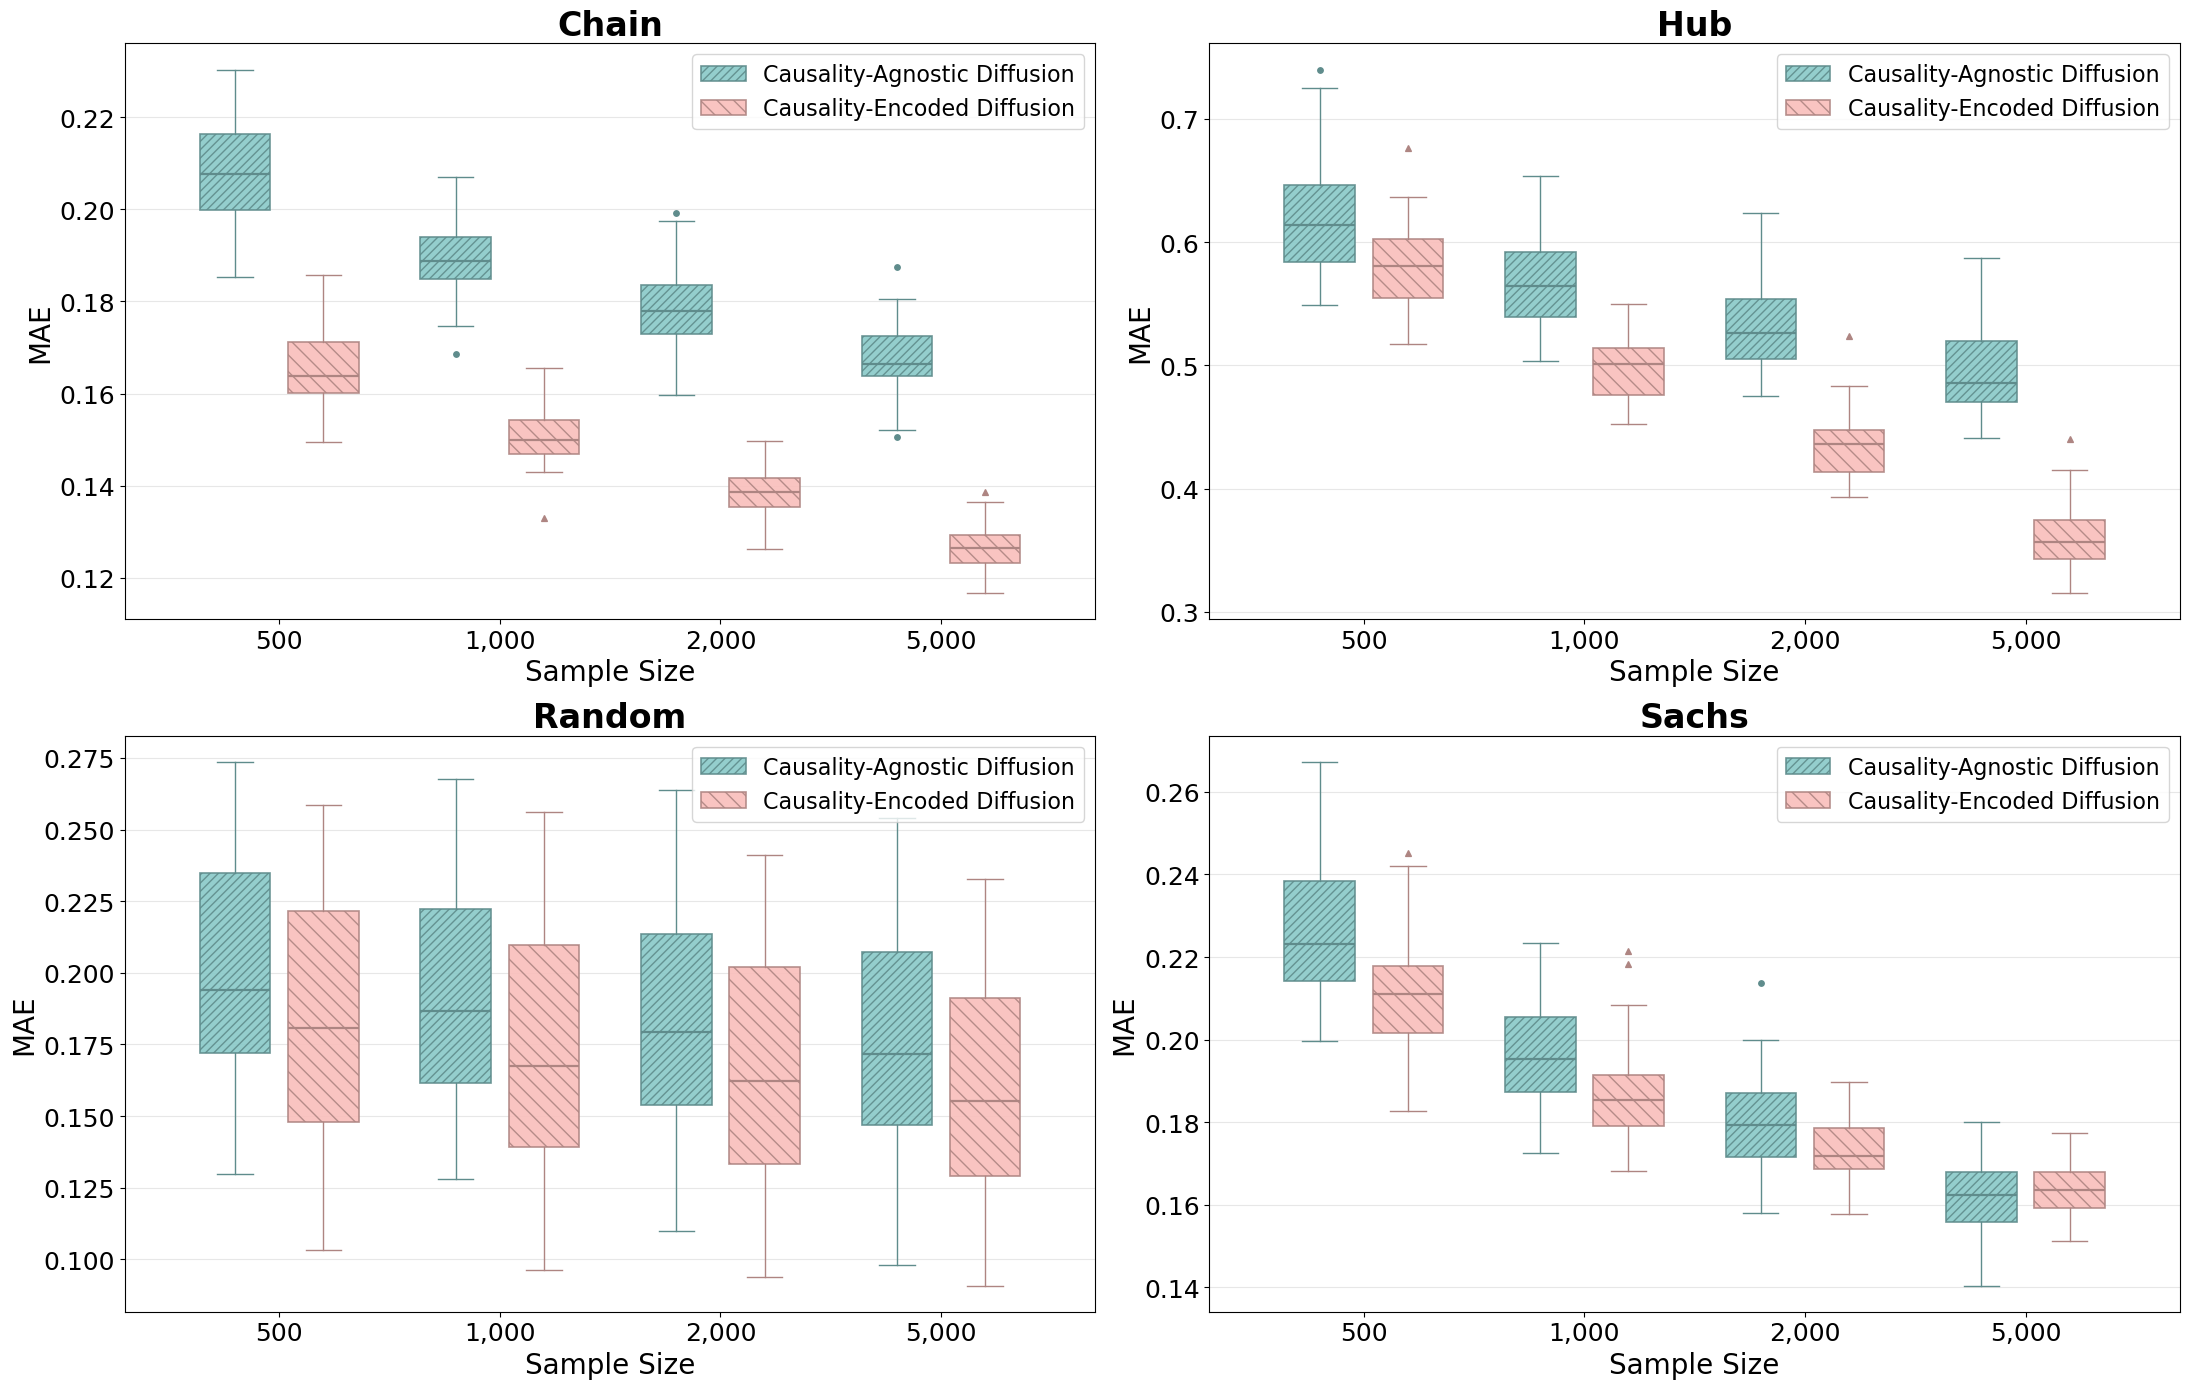


LONG CHAIN COMPARISON Summary Statistics:
--------------------------------------------------

GENERAL DIFFUSION:
  Sample Size 500: Mean=0.207889, Std=0.010771, N=50
  Sample Size 1,000: Mean=0.189001, Std=0.007553, N=50
  Sample Size 2,000: Mean=0.178363, Std=0.009363, N=50
  Sample Size 5,000: Mean=0.167392, Std=0.007173, N=50

CAUSALITY-ENCODED DIFFUSION:
  Sample Size 500: Mean=0.164872, Std=0.007309, N=50
  Sample Size 1,000: Mean=0.150949, Std=0.006094, N=50
  Sample Size 2,000: Mean=0.138591, Std=0.005111, N=50
  Sample Size 5,000: Mean=0.126717, Std=0.004612, N=50

HUB COMPARISON Summary Statistics:
--------------------------------------------------

GENERAL DIFFUSION:
  Sample Size 500: Mean=0.620271, Std=0.045594, N=50
  Sample Size 1,000: Mean=0.567386, Std=0.035332, N=50
  Sample Size 2,000: Mean=0.533234, Std=0.033764, N=50
  Sample Size 5,000: Mean=0.495109, Std=0.034885, N=50

CAUSALITY-ENCODED DIFFUSION:
  Sample Size 500: Mean=0.579607, Std=0.035608, N=50
  Sample Siz

In [5]:
from matplotlib.patches import Patch

# ── Visual encoding (color + hatch + marker) ──────────────────────────────────
# Two methods are distinguished by THREE redundant cues so the figure is
# readable in greyscale and by colour-blind / visually-impaired readers:
#   1. Fill colour   (teal vs. pink)
#   2. Hatch pattern (forward-slash '////' vs. back-slash '\\\\')
#   3. Outlier marker shape (circle 'o' vs. triangle-up '^')

FRAMEWORK_ORDER = ['Causality-Agnostic Diffusion', 'Causality-Encoded Diffusion']
FILL_COLORS     = ['#89C9C8', '#F9BEBB']       # teal / pink
EDGE_COLORS     = ['#5F8C8C', '#AE8582']       # darker matching borders
HATCHES         = ['////', '\\\\']          # forward-slash / back-slash
FLIER_MARKERS   = ['o', '^']                   # circle / triangle-up

TITLE_MAP = {
    "hub":        "Hub",
    "long_chain": "Chain",
    "random_dag": "Random",
    "sachs":      "Sachs",
}

FRAMEWORK_MAPPING = {
    'standard':    'Causality-Agnostic Diffusion',
    'conditional': 'Causality-Encoded Diffusion',
}


def _draw_boxplot_on_ax(ax, df, experiment_name):
    """Draw a single accessibility-friendly boxplot panel onto *ax*."""

    plt.style.use('default')

    df_plot = df.copy()
    df_plot['framework_label'] = df_plot['framework'].map(FRAMEWORK_MAPPING)

    sample_sizes_sorted = sorted(df['n_samples_train'].unique())

    positions       = []
    data_to_plot    = []
    box_colors      = []
    box_edge_colors = []
    box_hatches     = []
    flier_markers   = []

    width = 0.4
    for i, n_samples in enumerate(sample_sizes_sorted):
        for j, framework in enumerate(FRAMEWORK_ORDER):
            data_subset = df_plot[
                (df_plot['n_samples_train'] == n_samples) &
                (df_plot['framework_label'] == framework)
            ]['mae'].values

            pos = i + j * width - width / 2
            positions.append(pos)
            data_to_plot.append(data_subset)
            box_colors.append(FILL_COLORS[j])
            box_edge_colors.append(EDGE_COLORS[j])
            box_hatches.append(HATCHES[j])
            flier_markers.append(FLIER_MARKERS[j])

    bp = ax.boxplot(
        data_to_plot,
        positions=positions,
        widths=width * 0.8,
        patch_artist=True,
        showfliers=True,
    )

    # Style boxes (fill, hatch, border)
    for i, (patch, face, edge, hatch) in enumerate(
        zip(bp['boxes'], box_colors, box_edge_colors, box_hatches)
    ):
        patch.set_facecolor(face)
        patch.set_edgecolor(edge)
        patch.set_hatch(hatch)
        patch.set_alpha(0.9)
        patch.set_linewidth(1.2)

        for w in bp['whiskers'][2 * i: 2 * i + 2]:
            w.set_color(edge)
            w.set_linewidth(1.0)
        for c in bp['caps'][2 * i: 2 * i + 2]:
            c.set_color(edge)
            c.set_linewidth(1.0)

    # Median lines
    for median, edge in zip(bp['medians'], box_edge_colors):
        median.set_color(edge)
        median.set_linewidth(1.6)

    # Outlier markers — different shape per method
    for flier, edge, marker in zip(bp['fliers'], box_edge_colors, flier_markers):
        flier.set_marker(marker)
        flier.set_markersize(4)
        flier.set_markerfacecolor(edge)
        flier.set_markeredgecolor(edge)
        flier.set_markeredgewidth(0.9)
        flier.set_alpha(1.0)

    title = TITLE_MAP.get(experiment_name, experiment_name.replace('_', ' ').title())
    ax.set_title(title, fontsize=24, fontweight='bold')
    ax.set_xlabel('Sample Size', fontsize=20)
    ax.set_ylabel('MAE', fontsize=20)
    ax.grid(True, alpha=0.3, axis='y')

    ax.set_xticks(range(len(sample_sizes_sorted)))
    ax.set_xticklabels([f'{int(x):,}' for x in sample_sizes_sorted], fontsize=18)
    ax.tick_params(axis='y', labelsize=18)

    # Legend (colour + hatch shown together)
    legend_elements = [
        Patch(
            facecolor=FILL_COLORS[0], edgecolor=EDGE_COLORS[0],
            hatch=HATCHES[0], linewidth=1.2, alpha=0.9,
            label='Causality-Agnostic Diffusion',
        ),
        Patch(
            facecolor=FILL_COLORS[1], edgecolor=EDGE_COLORS[1],
            hatch=HATCHES[1], linewidth=1.2, alpha=0.9,
            label='Causality-Encoded Diffusion',
        ),
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=16)

    return ax


def print_summary_stats(df, experiment_name):
    """Print per-framework summary statistics."""
    print(f"\n{experiment_name.upper().replace('_', ' ')} COMPARISON Summary Statistics:")
    print("-" * 50)
    framework_labels = {
        'standard':    'GENERAL DIFFUSION',
        'conditional': 'CAUSALITY-ENCODED DIFFUSION',
    }
    for framework in ['standard', 'conditional']:
        print(f"\n{framework_labels[framework]}:")
        framework_data = df[df['framework'] == framework]
        for n_samples in sorted(df['n_samples_train'].unique()):
            size_data = framework_data[
                framework_data['n_samples_train'] == n_samples
            ]['mae']
            if len(size_data) > 0:
                print(
                    f"  Sample Size {int(n_samples):,}: "
                    f"Mean={size_data.mean():.6f}, "
                    f"Std={size_data.std():.6f}, "
                    f"N={len(size_data)}"
                )


# ── Build 2×2 combined figure ─────────────────────────────────────────────────
# Panel order (left-to-right, top-to-bottom): Chain, Hub, Random, Sachs
panel_specs = [
    (long_chain_df, "long_chain"),
    (hub_df,        "hub"),
    (random_dag_df, "random_dag"),
    (sachs_df,      "sachs"),
]

print("Creating 2\u00d72 combined framework comparison figure...")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(22, 14))

for ax, (df_panel, exp_name) in zip(axes.flat, panel_specs):
    _draw_boxplot_on_ax(ax, df_panel, exp_name)

plt.tight_layout()

output_pdf = RESULTS_DIR / 'framework_comparison_2x2.pdf'
fig.savefig(output_pdf, bbox_inches='tight')
print(f"Combined 2\u00d72 figure saved to: {output_pdf}")

plt.show()

# Print summary statistics for all panels
for df_panel, exp_name in panel_specs:
    print_summary_stats(df_panel, exp_name)


## 3. Summary and Conclusions

The notebook generates framework comparison boxplots for each graph structure (hub, long chain, random DAG, and sachs), showing how MAE varies across sample sizes for Causality-Agnostic Diffusion vs Causality-Encoded Diffusion frameworks.

**Key improvements in updated version:**
- Data now based on M conditioning vectors per seed (more robust evaluation)
- MSE/MAE computed by averaging over all M predictions
- Consistent data format across all comparison files
- Y-axis starts from 0 for better visual comparison


In [ ]:
print("ANALYSIS COMPLETE!")
print("=" * 50)
print("Generated visualizations:")
print("  Combined 2x2 framework comparison figure:")
print("    - framework_comparison_2x2.pdf")
print()
print("Key capabilities of this notebook:")
print("  - Load and analyze results from hub, long chain, random DAG, and sachs comparison experiments")
print("  - Create accessibility-friendly boxplots (colour + hatch + marker shape)")
print("  - Compare Causality-Agnostic Diffusion vs Causality-Encoded Diffusion performance across sample sizes")
print("  - Analyze MAE differences across different graph structures and frameworks")
print("  - Generate detailed statistical summaries")
print()
print(f"Total data points analyzed: {len(combined_df)}")
print(f"Experiments: {', '.join(sorted(combined_df['experiment'].unique()))}")
print(f"Frameworks: {', '.join(sorted(combined_df['framework'].unique()))}")
print(f"Sample sizes: {sorted(combined_df['n_samples_train'].unique())}")
print()
print("Ready for further analysis or customization!")
